In [1]:
import os 
from skimage.io import imread
from skimage.transform import resize

In [2]:
print("testing...") 

testing...


In [3]:
X = [] 
y = [] 

for category in ["cats", "dogs"]: 
    for filename in os.listdir(f"train/{category}"): 
        img = imread(os.path.join(f"train/{category}", filename), as_gray=True) 
        img = resize(img, (64, 64)) 
        X.append(img.flatten()) 
        y.append(category) 

In [4]:
print(X) 

[array([0.96121399, 0.96431768, 0.97176854, ..., 0.8529489 , 0.83251674,
       0.82995924]), array([0.85221524, 0.85085166, 0.84114788, ..., 0.7831184 , 0.77633843,
       0.76733416]), array([0.23326516, 0.23326516, 0.23326504, ..., 0.98126326, 0.98126309,
       0.98126314]), array([0.19698287, 0.22884424, 0.42197836, ..., 0.67915661, 0.70251748,
       0.71008279]), array([0.21209894, 0.19170524, 0.19540084, ..., 0.33936241, 0.28079245,
       0.3038545 ]), array([0.99773804, 0.99773804, 0.99773804, ..., 0.99773804, 0.99773804,
       0.99773804]), array([0.25561654, 0.26797578, 0.27574616, ..., 0.62428309, 0.60529251,
       0.59839857]), array([0.69463823, 0.69884554, 0.70128049, ..., 0.30824103, 0.15219092,
       0.12472815]), array([0.01690775, 0.02120821, 0.03397372, ..., 0.26490564, 0.24689369,
       0.22634046]), array([0.92440392, 0.92440392, 0.92440401, ..., 0.98156991, 0.98126324,
       0.98126314]), array([0.05711603, 0.06187739, 0.1658179 , ..., 0.33574679, 0.3268094

In [5]:
print(y) 

['cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats',

In [6]:
from sklearn.model_selection import train_test_split 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [7]:
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(max_iter=8000) 
clf.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,8000
,multi_class,'deprecated'


In [8]:
clf.score(X_test, y_test)

0.5357142857142857

In [9]:
clf.predict(X_test)

array(['dogs', 'cats', 'cats', 'cats', 'dogs', 'cats', 'dogs', 'cats',
       'cats', 'cats', 'cats', 'cats', 'dogs', 'cats', 'dogs', 'dogs',
       'cats', 'dogs', 'dogs', 'dogs', 'cats', 'cats', 'cats', 'dogs',
       'cats', 'dogs', 'dogs', 'dogs', 'dogs', 'dogs', 'cats', 'cats',
       'cats', 'cats', 'dogs', 'cats', 'cats', 'cats', 'cats', 'dogs',
       'cats', 'cats', 'dogs', 'cats', 'cats', 'dogs', 'cats', 'dogs',
       'cats', 'cats', 'cats', 'dogs', 'cats', 'dogs', 'cats', 'cats',
       'cats', 'dogs', 'dogs', 'dogs', 'cats', 'cats', 'dogs', 'cats',
       'cats', 'dogs', 'dogs', 'dogs', 'cats', 'cats', 'cats', 'cats',
       'dogs', 'dogs', 'cats', 'dogs', 'dogs', 'dogs', 'dogs', 'cats',
       'dogs', 'dogs', 'cats', 'dogs', 'cats', 'dogs', 'cats', 'dogs',
       'dogs', 'cats', 'cats', 'dogs', 'cats', 'cats', 'dogs', 'cats',
       'dogs', 'dogs', 'cats', 'dogs', 'dogs', 'dogs', 'dogs', 'dogs',
       'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'cats', 'dogs'],
     

Matplotlib is building the font cache; this may take a moment.


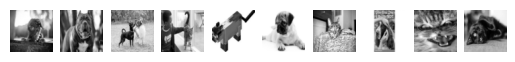

In [10]:
import matplotlib.pyplot as plt 

for index in range(0, 10): 
    plt.subplot(1, 10, index + 1) 
    plt.imshow(X_test[index].reshape(64,64), cmap='gray') 
    plt.axis("off")

plt.show()

In [16]:
import numpy as np 

IMG_SIZE = (64, 64)

def preprocess_image(path: str) -> np.ndarray:
    img = imread(path, as_gray=True)          # grayscale
    img = resize(img, IMG_SIZE, anti_aliasing=True)  # 64x64
    return img.flatten().astype(np.float32)    # shape: (4096,)

In [18]:
x_new = preprocess_image("cat.png").reshape(1, -1)  # (1, 4096)
pred_label = clf.predict(x_new)[0]
print(pred_label) 

cats
